# Plot simulation

This notebook is to perform a SHAP analysis to explain the prediction of the nowcasting model

# Choose the lead time and the classification threshold

In [359]:
lead_time = 1

In [360]:
resolution = 0.1

# Module import

In [361]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle                
import cartopy.crs as ccrs                              
import cartopy.feature as cfeature                   
import tensorflow as tf                                                                 
from joblib import load             
from scipy.ndimage import gaussian_filter                                              
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'                    # '0'=all, '1'=info, '2'=warning, '3'=error

# Load artificial data

In [ ]:
test = pd.read_csv(f'./data/single/artificial-data-{resolution}.csv')

In [363]:
input_headers = ['year', 'month', 'day', 'hour', 'minute']    
for prefix in ['lat', 'lon', 'wp', 'size', 'd', 'mask']:
    input_headers.extend([f'{prefix}{i}' for i in range(1, 4)])

In [364]:
X_test = test[input_headers]

In [365]:
for col in ['size1', 'size2', 'size3', 'wp1', 'wp2', 'wp3', 'd1', 'd2', 'd3']:
    X_test.loc[:, col] = np.log1p(X_test[col])

# Scaling

In [366]:
# Exclude mask columns from scaling
mask_cols = ['mask1', 'mask2', 'mask3']

# Final list of features to scale
cols_to_scale = [col for col in X_test.columns 
                 if col not in mask_cols]

scaler = load('../../model/dakar/lead-time-t1/model-dakar-t1.pkl')

X_test_scaled = X_test.copy()
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Loading models

In [367]:
model = tf.keras.models.load_model(f'../../model/dakar/lead-time-t{lead_time}/model-dakar-t{lead_time}.keras')

# Inference

In [368]:
y_pred = model.predict(X_test_scaled).flatten()

462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step


# Geolocation

In [369]:
Dakar_lon = -17.467686
Dakar_lat = 14.716677

In [370]:
# Define resolution (change as needed)
lat_resolution = lon_resolution = resolution  # degrees


CONTEXT_DOMAIN_LAT_MIN, CONTEXT_DOMAIN_LAT_MAX = 8.69, 20.69
CONTEXT_DOMAIN_LON_MIN, CONTEXT_DOMAIN_LON_MAX = -23.45, -11.45


# Create arrays of lats and lons
lats = np.arange(CONTEXT_DOMAIN_LAT_MIN, CONTEXT_DOMAIN_LAT_MAX + lat_resolution, lat_resolution)
lons = np.arange(CONTEXT_DOMAIN_LON_MIN, CONTEXT_DOMAIN_LON_MAX + lon_resolution, lon_resolution)

# Create meshgrid
lon_grid, lat_grid = np.meshgrid(lons, lats)

In [371]:
probability = y_pred.reshape(lon_grid.shape)

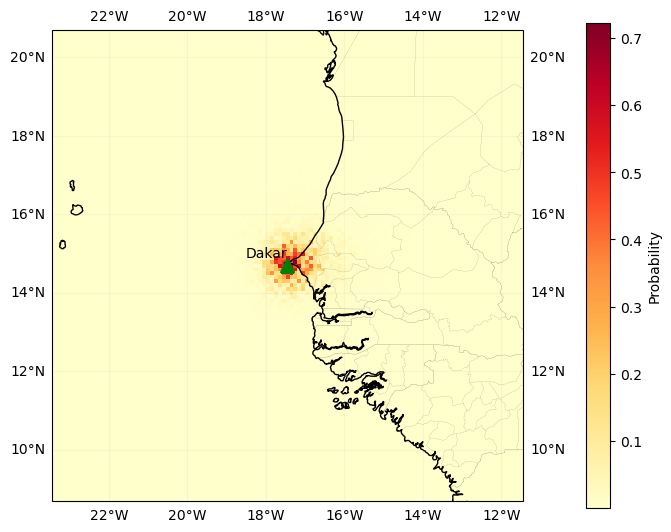

In [372]:
# Define extent
extent = (CONTEXT_DOMAIN_LON_MIN, CONTEXT_DOMAIN_LON_MAX, CONTEXT_DOMAIN_LAT_MIN, CONTEXT_DOMAIN_LAT_MAX)

# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Set map extent
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.1)
ax.add_feature(cfeature.COASTLINE, edgecolor='black')

# Force LAND to be white
ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

gl = ax.gridlines(xlocs=np.arange(-26, -8, 2), 
                  ylocs=np.arange(8, 23, 2), 
                  draw_labels=True, 
                  crs=ccrs.PlateCarree(),
                  alpha=0.1
                )

# Add administrative borders
admin_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
)

# display core data
ax.add_feature(admin_borders, edgecolor='black', linewidth=0.06)

pcm = ax.pcolormesh(lons, lats, probability, cmap="YlOrRd", transform=ccrs.PlateCarree())
plt.colorbar(pcm, ax=ax, label='Probability', shrink=0.5, pad=0.1)

# contour = plt.contour(lons, lats, gaussian_probability, colors='white', levels=5)
# plt.clabel(contour, fontsize=8, fmt='%d')

# Plot a marker at Dakar's location
plt.plot(Dakar_lon, Dakar_lat, marker="^", color="green", markersize=10)
plt.text(Dakar_lon, Dakar_lat+0.1, "Dakar", ha="right", va="bottom")
plt.tight_layout()
plt.show()

In [373]:
gaussian_probability = gaussian_filter(probability, sigma=3)

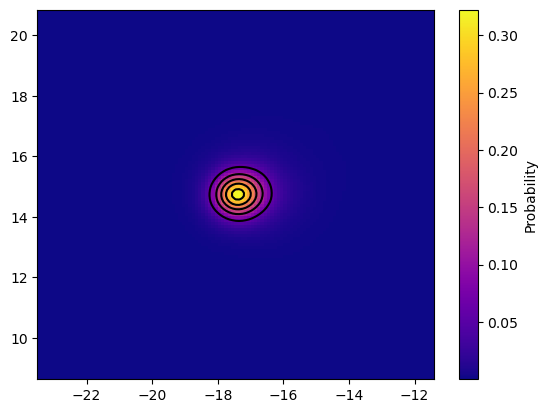

In [374]:
plt.pcolormesh(lons, lats, gaussian_probability, cmap="plasma")
plt.colorbar(label='Probability')
contour = plt.contour(lons, lats, gaussian_probability, colors='black', levels=5)
#plt.clabel(contour, inline=True, fontsize=8, fmt='%d')
plt.show()

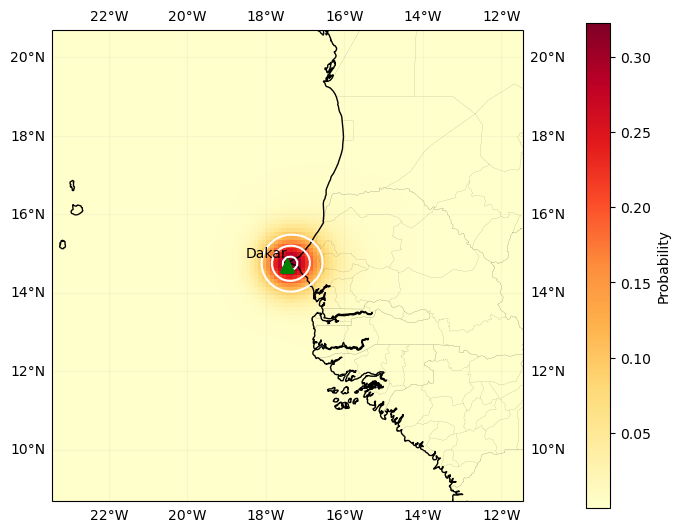

In [375]:
# Define extent
extent = (CONTEXT_DOMAIN_LON_MIN, CONTEXT_DOMAIN_LON_MAX, CONTEXT_DOMAIN_LAT_MIN, CONTEXT_DOMAIN_LAT_MAX)

# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Set map extent
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.1)
ax.add_feature(cfeature.COASTLINE, edgecolor='black')

# Force LAND to be white
ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

gl = ax.gridlines(xlocs=np.arange(-26, -8, 2), 
                  ylocs=np.arange(8, 23, 2), 
                  draw_labels=True, 
                  crs=ccrs.PlateCarree(),
                  alpha=0.1
                )

# Add administrative borders
admin_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
)

# display core data
ax.add_feature(admin_borders, edgecolor='black', linewidth=0.06)

pcm = ax.pcolormesh(lons, lats, gaussian_probability, cmap="YlOrRd", transform=ccrs.PlateCarree())
plt.colorbar(pcm, ax=ax, label='Probability', shrink=0.5, pad=0.1)

contour = plt.contour(lons, lats, gaussian_probability, colors='white', levels=3)

# Plot a marker at Dakar's location
plt.plot(Dakar_lon, Dakar_lat, marker="^", color="green", markersize=10)
plt.text(Dakar_lon, Dakar_lat+0.1, "Dakar", ha="right", va="bottom")
plt.tight_layout()
plt.show()